# Customer Churn Prediction Project - Exploratory Data Analysis (EDA)
## Imports




In [1]:
import pandas as pds
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore') # clean output 
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

## load data

In [2]:
path_file="../data/df_churn.csv"

# fix path
# project_root = os.getcwd()  # cwd : current working directory
# csv_path = os.path.join(project_root, '..', 'data', 'df_churn.csv'

df=pds.read_csv(path_file)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Structure

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### `Total_Charges` => numeric

In [4]:
df['TotalCharges']=pds.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].head()

0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: float64

### Descriptive Statistics

In [5]:
display(df.describe())

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [7]:
df_columns=['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

### to drop

In [8]:
drop_col=['customerID']

## Univariate Analysis 
### Num Cols : Histogram


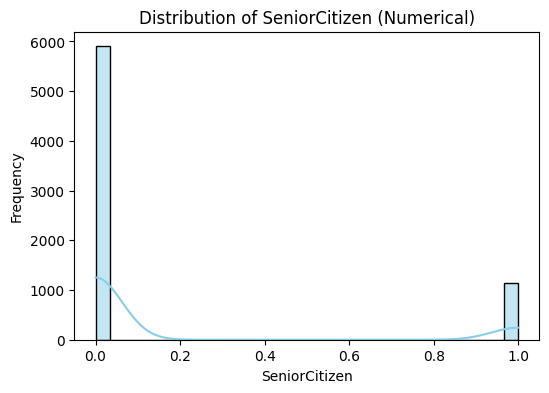

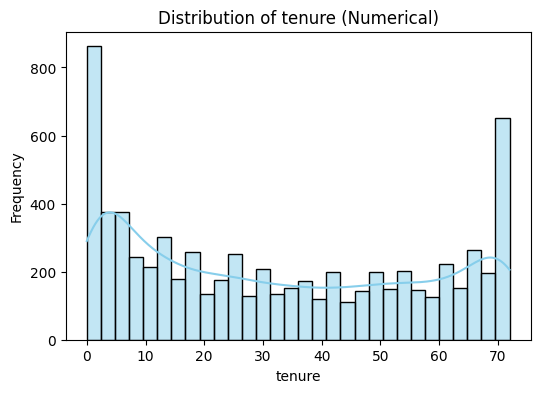

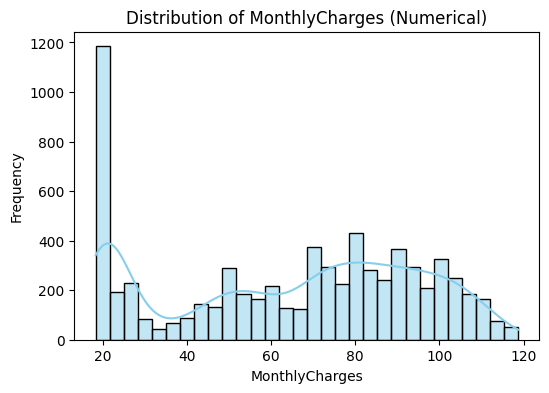

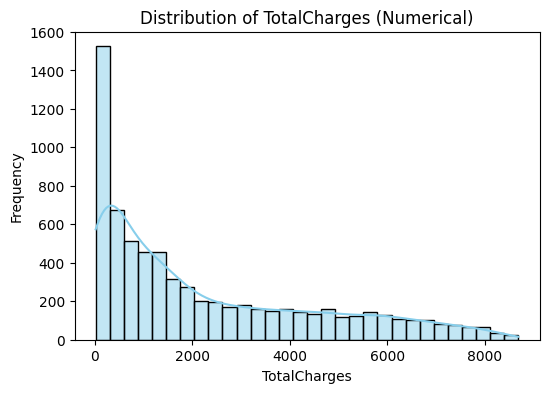

In [9]:
# column : Num -> 
df_copy=df.copy()
df_num=df_copy.select_dtypes(include=np.number)
for col in df_num.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df_num, x=col, kde=True, color='skyblue', bins=30)
    plt.title(f'Distribution of {col} (Numerical)')
    plt.ylabel('Frequency')
        

### Str Cols : Countplot

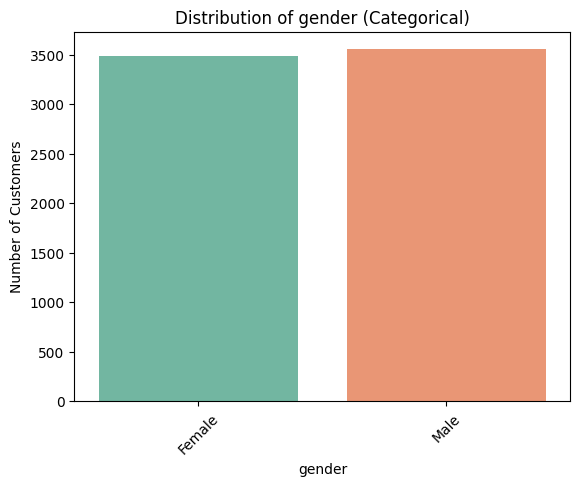

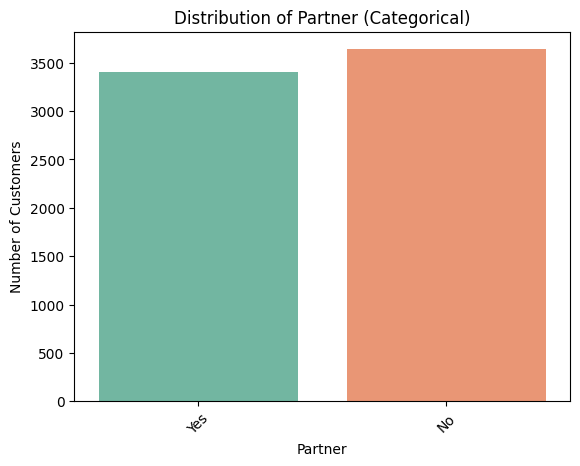

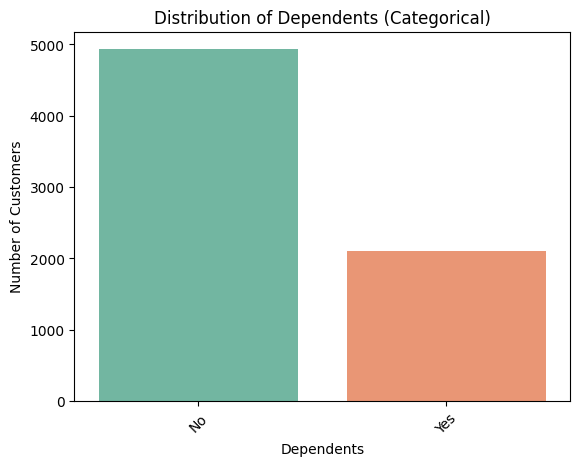

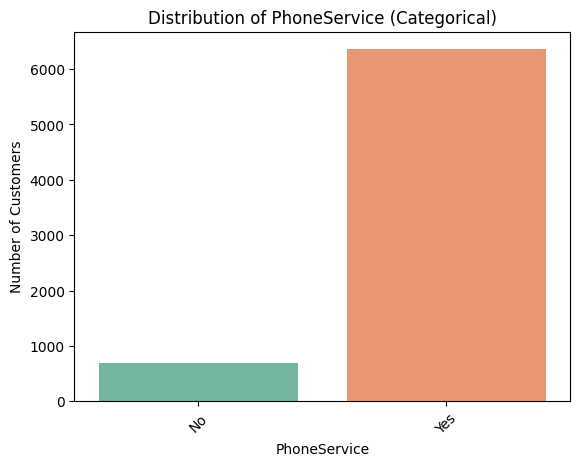

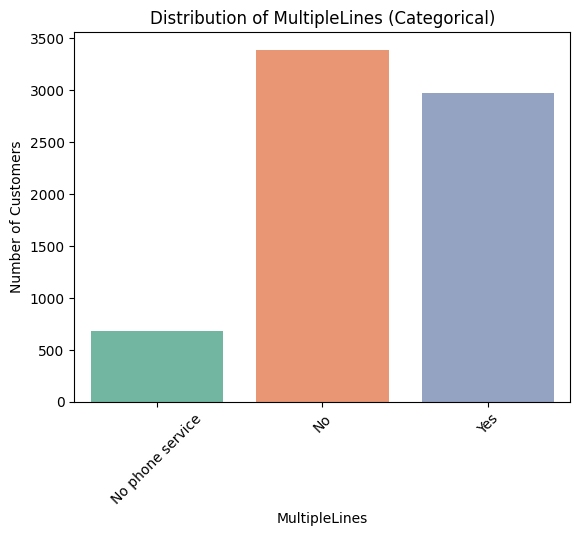

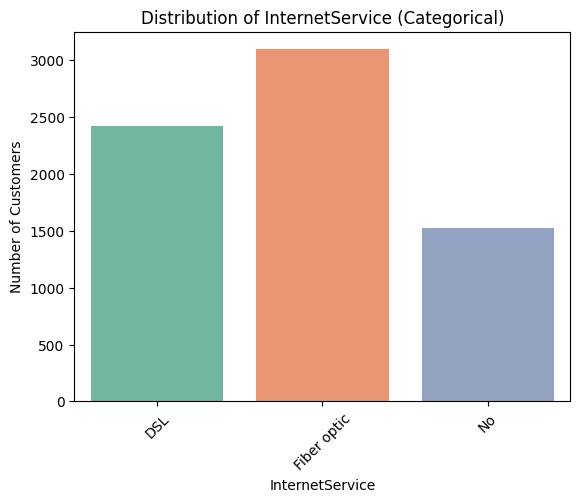

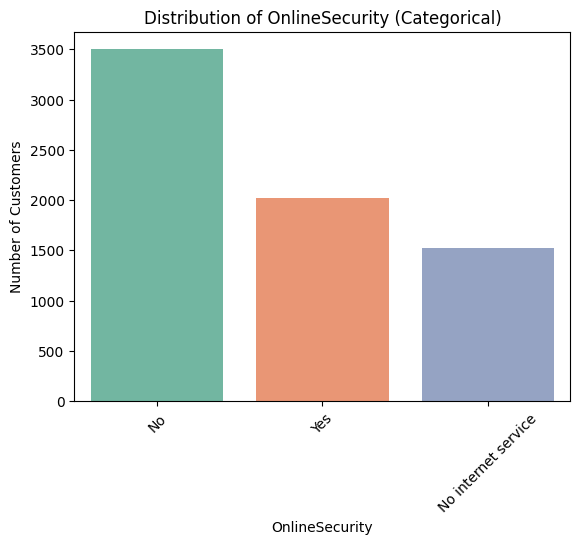

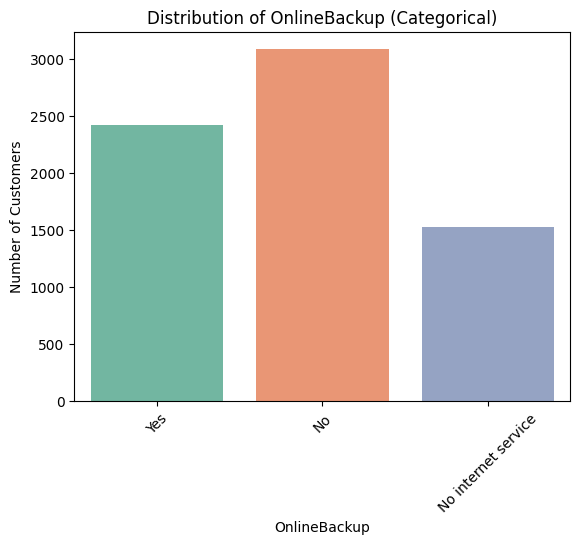

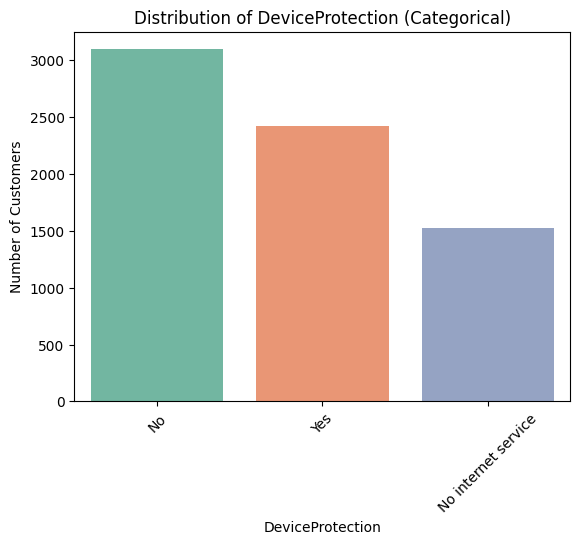

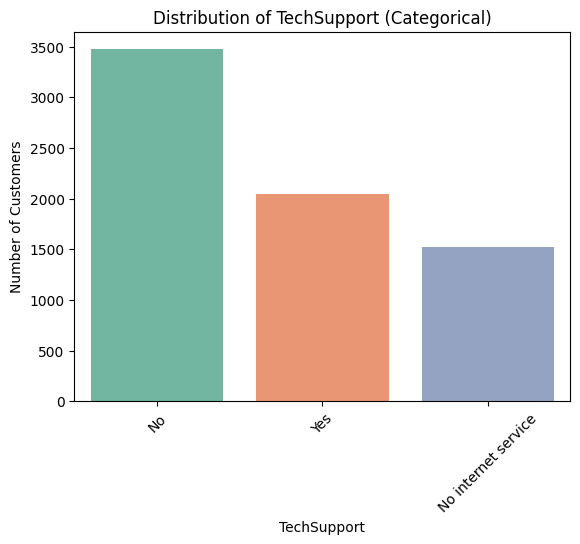

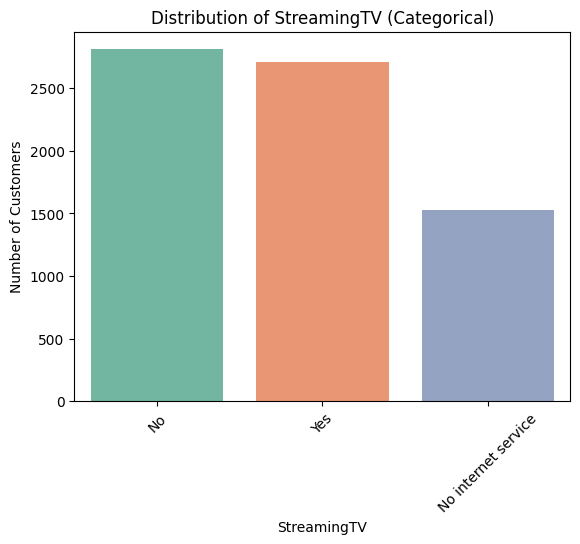

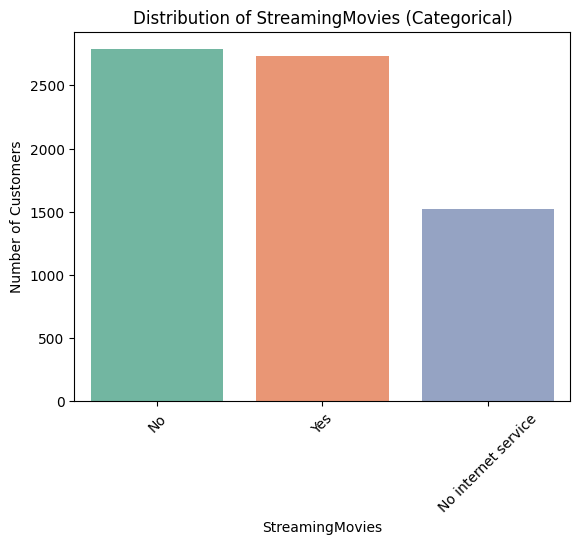

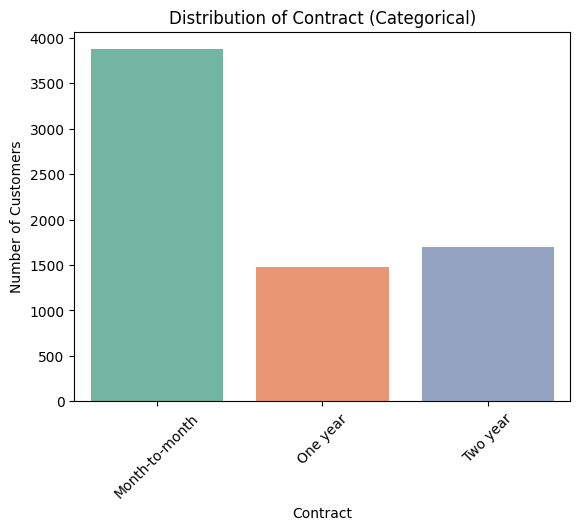

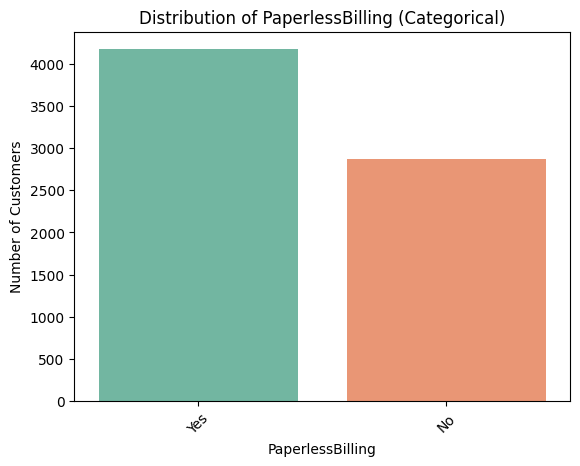

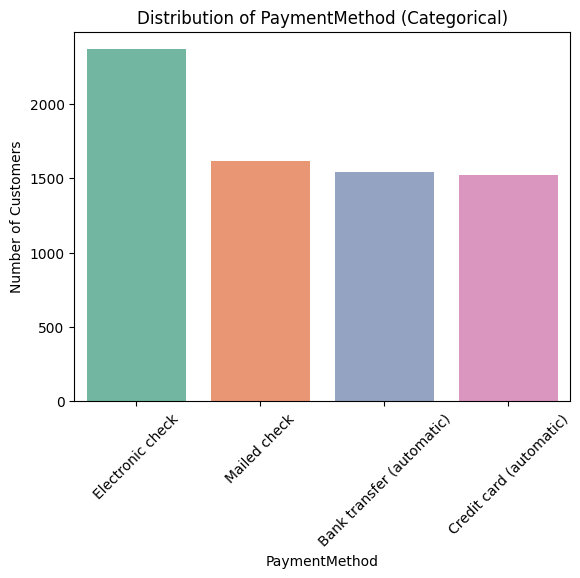

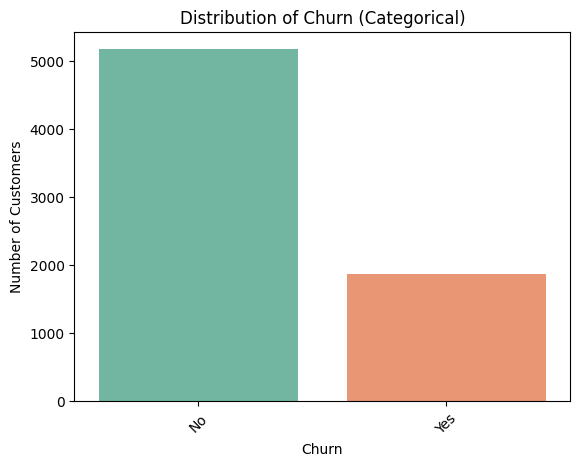

In [10]:
df_obj=df_copy.select_dtypes(include='object')
for col in df_obj.columns:
        if col == 'customerID':
                continue
        sns.countplot(data=df_obj, x=col, palette="Set2")
        plt.title(f'Distribution of {col} (Categorical)')
        plt.ylabel('Number of Customers')
        plt.xticks(rotation=45) #Label Rotation
        plt.xlabel(col)
        # plt.tight_layout() # Keeps the layout clean
        plt.show()

## Bivariate Analysis (Relationships with Churn)
### Str Cols vs Churn

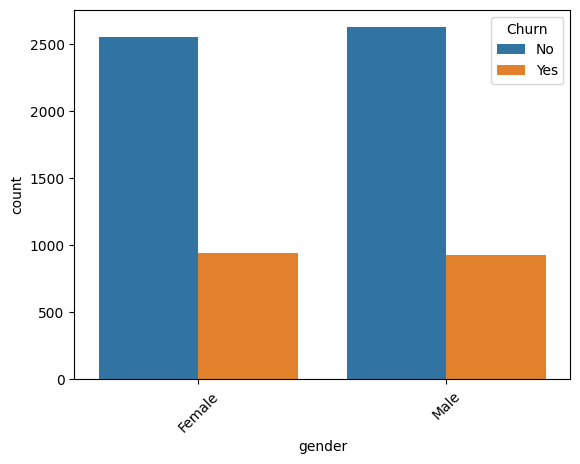

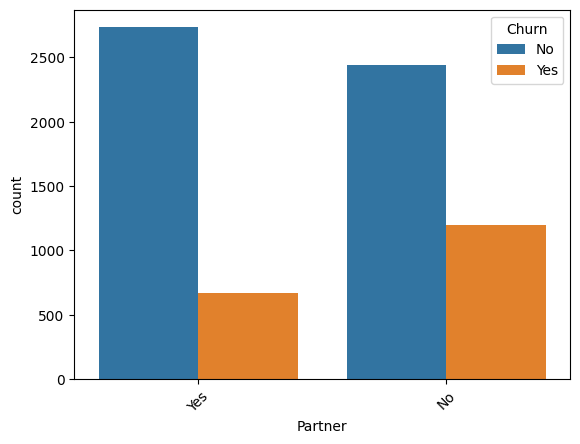

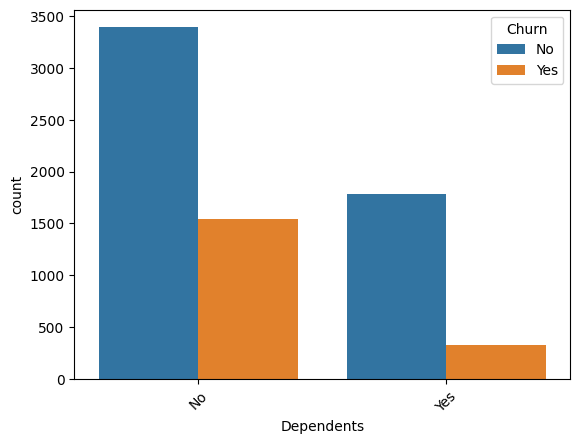

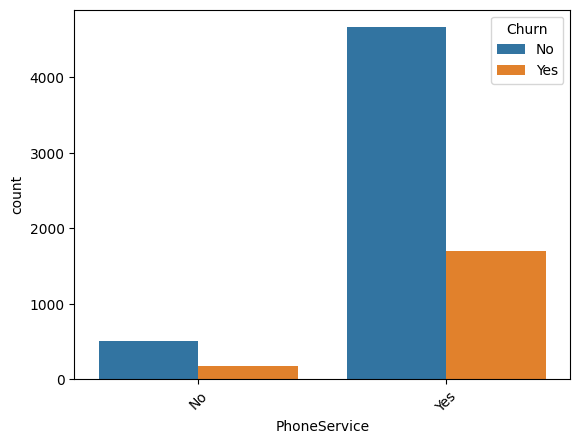

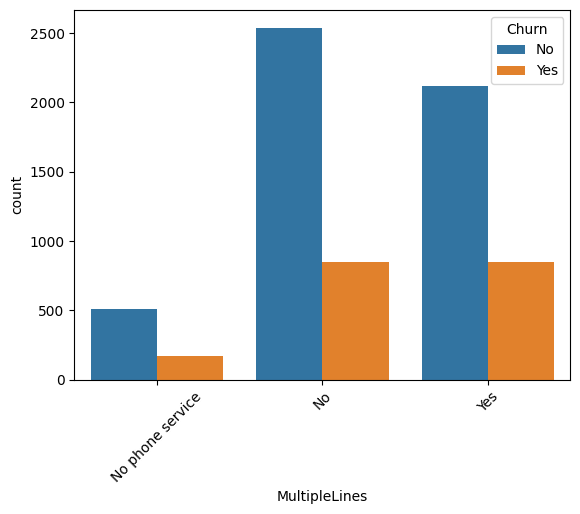

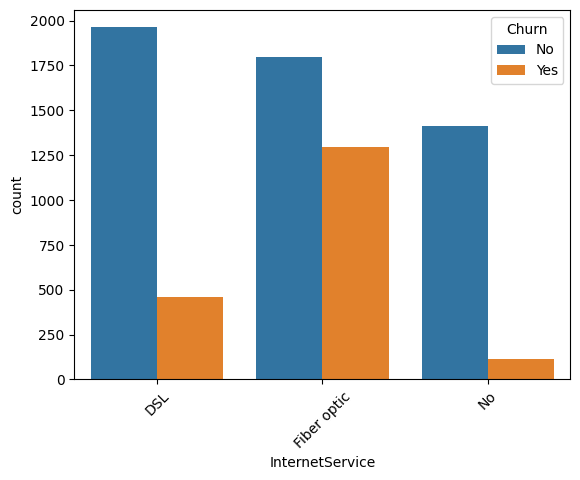

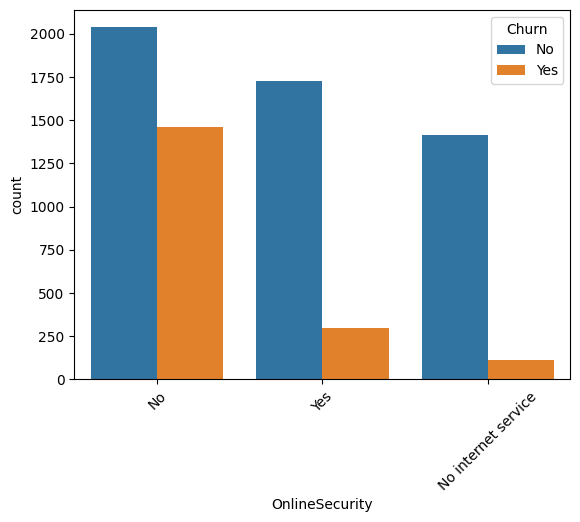

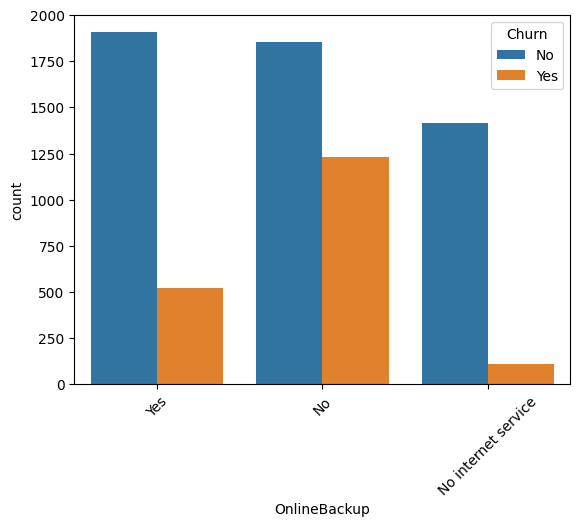

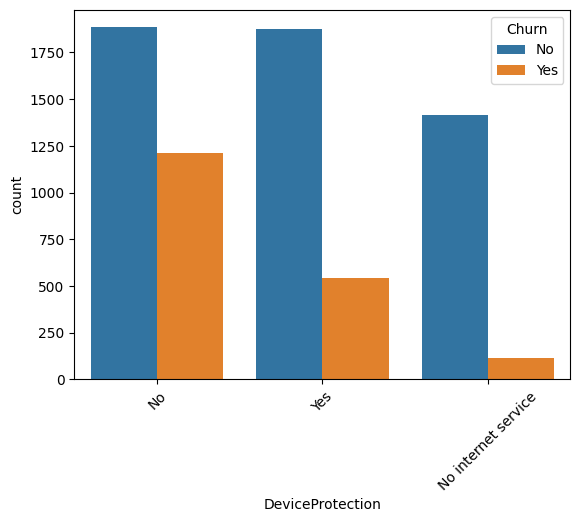

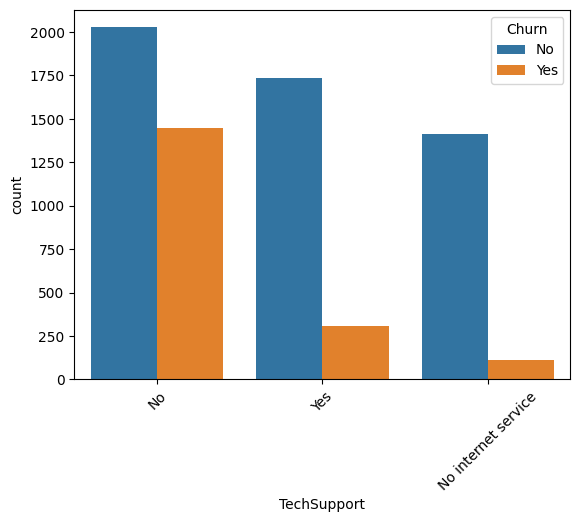

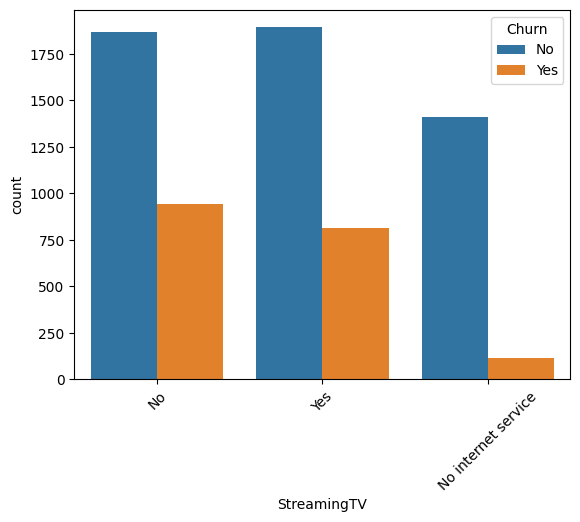

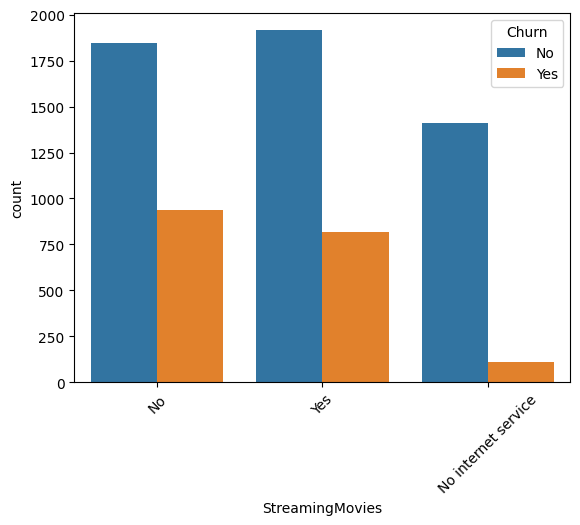

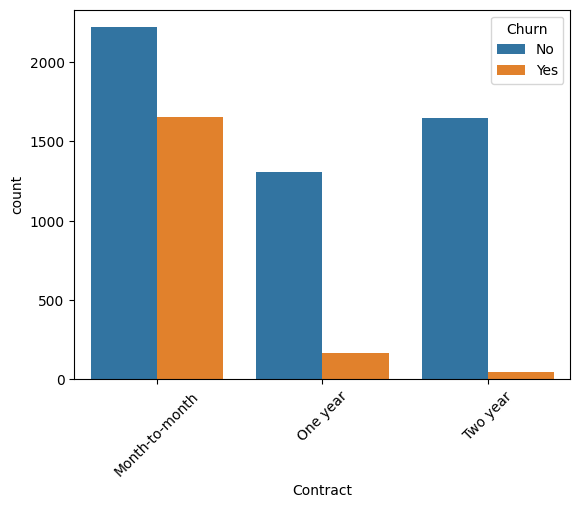

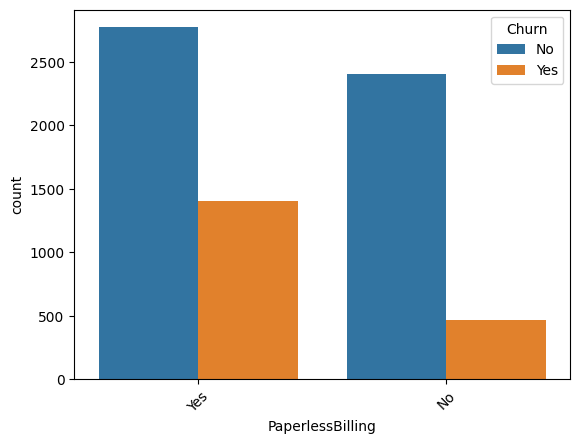

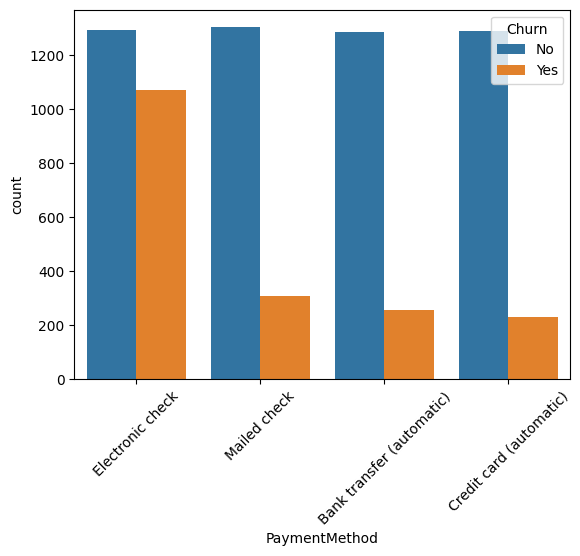

In [11]:
for col in df_obj.columns:
    if col not in drop_col and col != 'Churn': 
        sns.countplot(data=df_obj, x=col, hue='Churn')
        plt.xticks(rotation=45)
        plt.show()

### Num Cols vs Churn

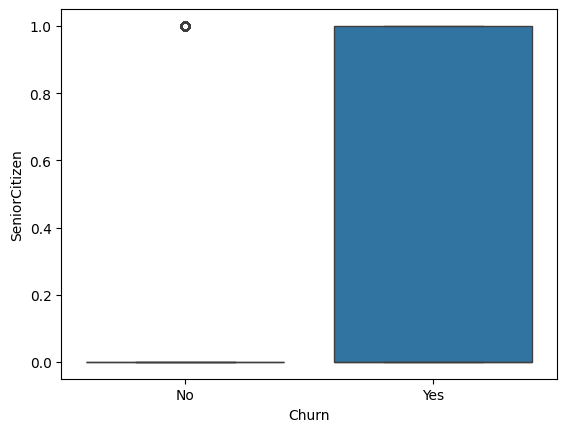

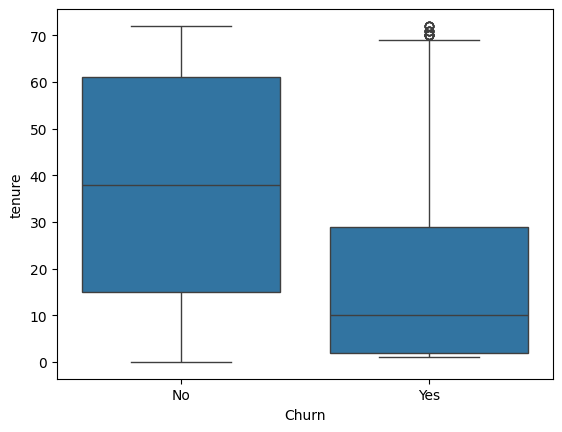

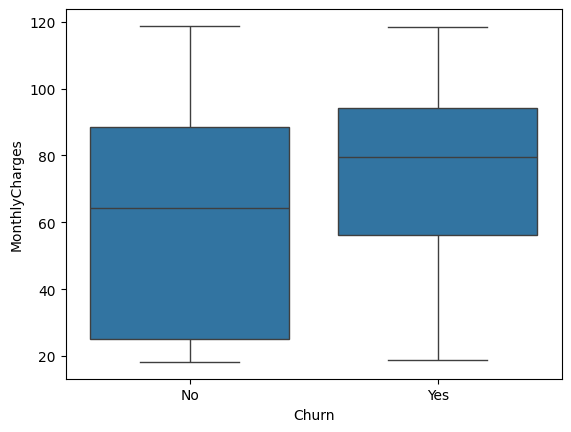

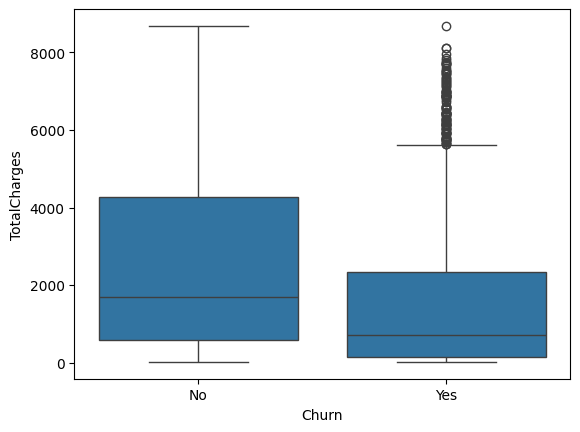

In [12]:
for col in df_num.columns:
    sns.boxplot(data=df_num.join(df_obj['Churn']), x='Churn', y=col)
    plt.show()

## Missing values

In [13]:
miss_val=df.isnull().sum()
print(miss_val[miss_val>0] if not miss_val[miss_val>0].empty else "No missing values found!")

TotalCharges    11
dtype: int64


## fill in

In [14]:
df_num['TotalCharges']=df_num['TotalCharges'].fillna(df_num['TotalCharges'].mean())  

## Encoding
### dictionary mapping

In [15]:
Churn_Map={'Yes' : 1, 'No' : 0}
df_copy['Churn']=df_copy["Churn"].map(Churn_Map)

### Label Encoder (2nd method)

In [16]:
l_e=LabelEncoder()
df_copy["Churn"]=l_e.fit_transform(df_copy["Churn"])    # df["item"] = Le.fit_transform(df["item"])
print(l_e.classes_)

[0 1]


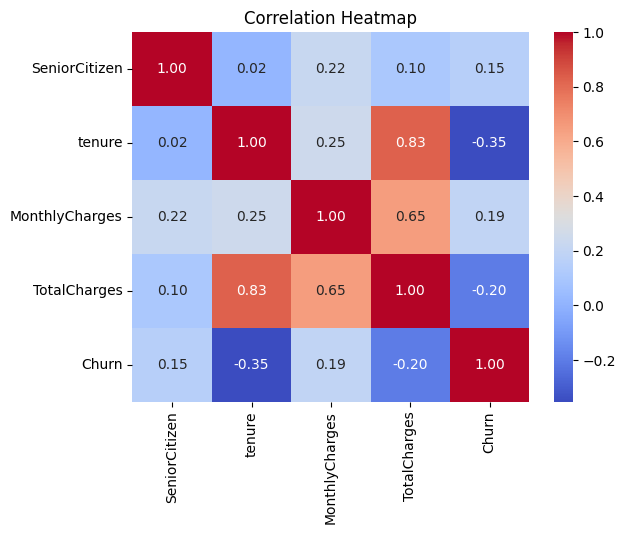

In [17]:
df_num=df_copy.select_dtypes(include=np.number)
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Normalization - MinMaxScaler

In [24]:
df_num = df_copy.select_dtypes(include=[np.number])    
df_num = df_num.drop("Churn", axis=1)
        
scaler = MinMaxScaler()
scaler.fit_transform(df_num)    

df_scaled = pds.DataFrame(
    scaler.fit_transform(df_num), 
    columns=df_num.columns, 
    index=df_num.index 
    )
df_num.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65


In [25]:
df_scaled.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0.0,0.013889,0.115423,0.001275
1,0.0,0.472222,0.385075,0.215867
2,0.0,0.027778,0.354229,0.010310
3,0.0,0.625000,0.239303,0.210241
4,0.0,0.027778,0.521891,0.015330
